# Tweet Sentiment Analysis: Logistic Regression & Naive Bayes

**Goal:** given a tweet, predict whether its sentiment is **positive (1)** or **negative (0)**.

We solve this with two classic models and compare them:

* **Logistic Regression** on two simple features (how "positive" and how "negative" a tweet's words are).
* **Naive Bayes** on word counts.

| Step | Tool | Why this tool |
|---|---|---|
| Cleaning, tokenizing, stemming, word counts, Laplace smoothing, log prior | NLTK | Built for text; has ready-made functions for these |
| Dataset, features, error analysis, word ratios | pandas | Tables are easy to filter, group and inspect |
| Train/test split, models, predictions, metrics | scikit-learn | Tested, standard implementations; no need to code them by hand |

> `utils.py` (with `process_tweet`) must sit in the same folder as this notebook.

## 1. Setup

**What:** import the libraries and download the two NLTK datasets we need: the tweets (`twitter_samples`) and a list of
common English words (`stopwords`).

**Why:** every later step depends on these. `process_tweet` (from `utils.py`) is imported here because it already does the
NLTK text cleaning for us, so we reuse it instead of rewriting it.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import twitter_samples
from nltk.probability import ConditionalFreqDist, FreqDist, LaplaceProbDist

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

from utils import process_tweet   # NLTK-based: cleans, tokenizes, removes stopwords, stems

nltk.download('twitter_samples', quiet=True)
nltk.download('stopwords', quiet=True)

True

## 2. Load data into a DataFrame

**What:** load 5,000 positive and 5,000 negative tweets and put them in one table with two columns: the text (`tweet`)
and the answer we want to predict (`label`).

**Why:** a model needs examples *with known answers* to learn from. The labels come from the dataset itself
(positive/negative tweets are stored in separate files). A single DataFrame keeps text and label together, so any
filtering or splitting we do later keeps each tweet matched to its label.

In [2]:
pos_tweets = twitter_samples.strings('positive_tweets.json')
neg_tweets = twitter_samples.strings('negative_tweets.json')

df = pd.DataFrame({
    'tweet': pos_tweets + neg_tweets,
    'label': [1] * len(pos_tweets) + [0] * len(neg_tweets),   # 1 = positive, 0 = negative
})

print(df.shape)
df.sample(5, random_state=1)

(10000, 2)


,tweet,label
9953,PAP of your spirit animal? — no i dont have :(...,0
3850,@iamsrk Lol. That look's like a scary room! Gh...,1
4962,"@keab42 I rang in sick yesterday, then told th...",1
3886,@daydreamlwt I need a rare sponsorship aswell ...,1
5437,what's wrong with me :(,0


## 3. Train / test split (80 / 20)

**What:** randomly set aside 20% of the tweets as a **test set** and keep 80% for **training**.

**Why:** a model must be judged on tweets it has never seen; otherwise a high score may only mean it memorized the
training data. `stratify=df['label']` keeps the positive/negative balance equal in both parts, and `random_state`
makes the split repeatable.

In [3]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df['label'].value_counts().to_dict(), test_df['label'].value_counts().to_dict())

{0: 4000, 1: 4000} {0: 1000, 1: 1000}


## 4. Preprocessing

**What:** turn every raw tweet into a short list of clean tokens. `process_tweet` lowercases the text, removes links,
@handles, `#` signs, stock tickers, stopwords (e.g. *the, is, I*) and punctuation, then **stems** each word
(*happy / happiness* become *happi*). Emoticons such as `:)` are kept because they carry strong sentiment.

**Why:** raw text is noisy. Without cleaning, *"Happy!"*, *"happy"* and *"HAPPY"* would count as three different words,
and filler words would drown out the useful ones. Cleaning shrinks the vocabulary and makes the counts more meaningful.

In [4]:
train_df['tokens'] = train_df['tweet'].apply(process_tweet)
test_df['tokens'] = test_df['tweet'].apply(process_tweet)

train_df[['tweet', 'tokens']].head(3)

,tweet,tokens
0,@cooldigangana @DiganganaS I want to attend ur...,"[want, attend, ur, birthday, plsss, :(]"
1,Thanks Jen...top weekend everyone! :) https://...,"[thank, jen, ..., top, weekend, everyon, :)]"
2,@chonchonnie I have yet to finish it! I'm stil...,"[yet, finish, still, season, 7, :(]"


## 5. Word counts per class

**What:** count how many times each word appears in positive tweets and how many times in negative tweets, and store
the result in a table (one row per word, one column per class).

**Why:** this table is the foundation for **both** models. Words that appear mostly in positive tweets (like `:)` or
*thank*) are signals of positive sentiment, and the reverse for negative ones. We count on the **training set only**,
so no information from the test tweets leaks into the model.

In [5]:
cfd = ConditionalFreqDist(
    (label, word)
    for label, tokens in zip(train_df['label'], train_df['tokens'])
    for word in tokens
)

freq_df = pd.DataFrame({'pos': dict(cfd[1]), 'neg': dict(cfd[0])}).fillna(0).astype(int)

print('Vocabulary size:', len(freq_df))
freq_df.sort_values('pos', ascending=False).head(8)

Vocabulary size: 9156


,pos,neg
:),2937,2
:-),568,0
:d,556,0
thank,516,83
follow,347,206
love,311,124
...,231,258
day,198,131


# Part A: Logistic Regression

## 6. Feature extraction

**What:** convert each tweet into just **two numbers**:
* `pos_freq`: the sum of the positive-class counts of all its words,
* `neg_freq`: the sum of the negative-class counts of all its words.

**Why:** a model cannot read words; it needs numbers. These two features summarise "how positive" and "how negative"
the wording is, using the table from step 5. A positive tweet gets a high `pos_freq` and a low `neg_freq`, so the two
classes become easy to separate. The `lambda` inside `.apply()` runs this small calculation on every tweet; words not
seen in training simply count as 0.

In [6]:
pos_map = freq_df['pos'].to_dict()
neg_map = freq_df['neg'].to_dict()

for part in (train_df, test_df):
    part['pos_freq'] = part['tokens'].apply(lambda toks: sum(pos_map.get(w, 0) for w in toks))
    part['neg_freq'] = part['tokens'].apply(lambda toks: sum(neg_map.get(w, 0) for w in toks))

feature_cols = ['pos_freq', 'neg_freq']
X_train_lr, y_train = train_df[feature_cols], train_df['label']
X_test_lr,  y_test  = test_df[feature_cols],  test_df['label']

X_train_lr.head()

,pos_freq,neg_freq
0,167,3875
1,3817,390
2,77,3803
3,3008,31
4,273,3766


## 7. Train the model

**What:** fit a `LogisticRegression` that learns one weight for each feature plus a bias, so it can turn
(`pos_freq`, `neg_freq`) into the **probability that a tweet is positive**. Above 0.5 means positive.

**Why logistic regression:** it is a simple, fast and easy-to-interpret classifier for two classes. The learned
weights tell us how much each feature pushes the prediction (a positive weight on `pos_freq` and a negative one on
`neg_freq` is what we expect).

**Why `StandardScaler`:** our features are counts in the thousands. Scaling them to a similar range helps the
optimizer converge reliably. A `Pipeline` bundles scaler and model so the same scaling is applied automatically at
prediction time.

In [7]:
lr_model = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression()),
])
lr_model.fit(X_train_lr, y_train)

print('Weights (pos_freq, neg_freq):', lr_model['clf'].coef_.round(3).ravel())
print('Bias:', lr_model['clf'].intercept_.round(3))

Weights (pos_freq, neg_freq): [  8.595 -10.676]
Bias: [-2.637]


## 8. Evaluate on the test set

**What:** predict the labels of the unseen test tweets and compare them with the true labels.

**Why:** accuracy alone can hide problems, so we report several metrics:
* **Accuracy**: share of all tweets classified correctly.
* **Precision**: of the tweets predicted positive, how many really are positive.
* **Recall**: of the truly positive tweets, how many we found.
* **F1**: a single score balancing precision and recall.
* **Confusion matrix**: shows the exact counts of right and wrong predictions per class (rows = true label,
  columns = predicted label), so we can see *which* kind of mistake the model makes.

The helper function is reused for Naive Bayes later, so both models are judged the same way.

              precision    recall  f1-score   support

    Negative     0.9970    0.9930    0.9950      1000
    Positive     0.9930    0.9970    0.9950      1000

    accuracy                         0.9950      2000
   macro avg     0.9950    0.9950    0.9950      2000
weighted avg     0.9950    0.9950    0.9950      2000



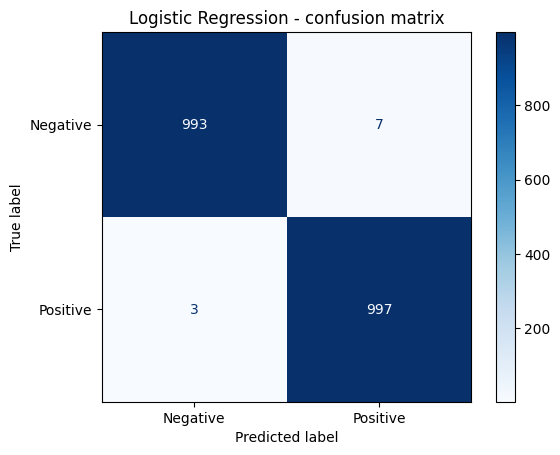

In [8]:
def evaluate(name, y_true, y_pred):
    """Print the main metrics, show the confusion matrix and return the scores as a dict."""
    scores = {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive'], digits=4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=['Negative', 'Positive'], cmap='Blues')
    plt.title(f'{name} - confusion matrix')
    plt.show()
    return scores

lr_pred = lr_model.predict(X_test_lr)
lr_scores = evaluate('Logistic Regression', y_test, lr_pred)

## 9. Error analysis

**What:** list the test tweets the model got wrong, next to their features and true label.

**Why:** a score tells us *how often* the model fails, but reading the failures tells us *why*. Typical causes are
sarcasm, mixed sentiment, or words that were rare in training. This is how we would decide what to improve next.

In [9]:
lr_errors = test_df.loc[test_df['label'] != lr_pred, ['tweet', 'tokens', 'pos_freq', 'neg_freq', 'label']].copy()
lr_errors['predicted'] = lr_pred[lr_errors.index]

print(f'{len(lr_errors)} misclassified tweets')
lr_errors.head(10)

10 misclassified tweets


,tweet,tokens,pos_freq,neg_freq,label,predicted
564,all time looww(:(,"[time, looww, (:]",102,139,0,1
731,"And oh great, I'm sharing a carriage with a gr...","[oh, great, share, carriag, group, middl, age,...",307,231,0,1
850,@ellekagaoan @chinmarquez Catch up once in a w...,"[catch, :(, >:d]",11,3652,1,0
863,@phenomyoutube u probs had more fun with david...,"[u, prob, fun, david]",248,183,0,1
923,"Sr. Financial Analyst - Expedia, Inc.: (#Belle...","[sr, financi, analyst, expedia, inc, bellevu, ...",68,26,0,1
1115,@bumkeyyfel b-butt : ( isn't black cat a bad l...,"[b-butt, black, cat, bad, luck, ene]",52,80,0,1
1189,@yongshwa huhu i know :-( thanks before satya! xx,"[huhu, know, :-(, thank, satya, xx]",681,629,0,1
1453,@bae_ts WHATEVER STIL L YOUNG &gt;:-(,"[whatev, stil, l, young, >:-(]",9,6,0,1
1662,@_sarah_mae omg you can't just tell this and d...,"[omg, can't, tell, say, :p, can't, wait, know,...",476,609,1,0
1882,Remember that one time I didn't go to flume/ka...,"[rememb, one, time, go, flume, kaytranada, alu...",491,842,1,0


# Part B: Naive Bayes

## 10. Log prior and Laplace-smoothed log likelihood (NLTK)

**What:** compute the two ingredients of Naive Bayes by hand with NLTK, so we can see how the model works.

* **Log prior** `= log(positive tweets) - log(negative tweets)`: how likely a tweet is positive *before* reading any word.
  It is 0 here because the classes are balanced.
* **Laplace smoothing** `(count + 1) / (N + V)`: adds 1 to every word count. NLTK's `LaplaceProbDist` does this for us.
  Without it, a word seen only in one class would get probability 0 in the other and wipe out the whole prediction.
* **Log likelihood** of a word `= log(P(word | positive) / P(word | negative))`: positive if the word leans positive,
  negative if it leans negative, near 0 if it is neutral. We use *logs* so that many small probabilities can be **added**
  instead of multiplied, which avoids numbers becoming too small for the computer.

To classify a tweet, add the log prior and the log likelihood of each of its words: a total above 0 means positive.

In [10]:
# log prior
label_fd = FreqDist(train_df['label'])
logprior = math.log(label_fd[1]) - math.log(label_fd[0])

# Laplace-smoothed word probabilities for each class
V = len(freq_df)
p_pos = LaplaceProbDist(cfd[1], bins=V)
p_neg = LaplaceProbDist(cfd[0], bins=V)

# log likelihood per word
freq_df['loglikelihood'] = pd.Series(freq_df.index, index=freq_df.index).apply(
    lambda w: math.log(p_pos.prob(w) / p_neg.prob(w)))

print('logprior:', logprior, '| V:', V)
freq_df.sort_values('loglikelihood').head(5)

logprior: 0.0 | V: 9156


,pos,neg,loglikelihood
:(,0,3646,-8.217800
:-(,0,409,-6.032297
》,0,180,-5.214637
♛,0,180,-5.214637
>:(,0,40,-3.729712


## 11. Train the model

**What:** fit scikit-learn's Naive Bayes on a **word-count matrix**: one row per tweet, one column per vocabulary word,
each cell holding how often that word occurs in the tweet.

**Why `CountVectorizer`:** it builds that matrix from our token lists. The small `lambda` tells it the tweets are
already tokenized, so it reuses our NLTK cleaning instead of redoing it.

**Why `MultinomialNB`:** it models word *counts* per class, which is exactly the calculation of step 10
(`alpha=1` is the same +1 Laplace smoothing). It is fast to train and a strong baseline for text.

In [11]:
nb_model = Pipeline([
    ('counts', CountVectorizer(analyzer=lambda tokens: tokens)),
    ('clf', MultinomialNB(alpha=1.0)),
])
nb_model.fit(train_df['tokens'], y_train)

print('Matrix shape (tweets x vocabulary):', nb_model['counts'].transform(train_df['tokens']).shape)

Matrix shape (tweets x vocabulary): (8000, 9156)


**Sanity check:** scikit-learn computes the log prior and log likelihoods internally. If our manual NLTK values from
step 10 match them, we know both routes describe the same model.

In [12]:
vocab_order = nb_model['counts'].get_feature_names_out()
sk_loglik = nb_model['clf'].feature_log_prob_[1] - nb_model['clf'].feature_log_prob_[0]

print('Log prior matches:     ', np.isclose(nb_model['clf'].class_log_prior_[1] - nb_model['clf'].class_log_prior_[0], logprior))
print('Log likelihood matches:', np.allclose(sk_loglik, freq_df.loc[vocab_order, 'loglikelihood']))

Log prior matches:      True
Log likelihood matches: True


## 12. Evaluate on the test set

**What:** predict the unseen test tweets with Naive Bayes and score them with the same `evaluate` function.

**Why:** using identical metrics and the same test set makes the comparison with Logistic Regression fair.

              precision    recall  f1-score   support

    Negative     0.9960    0.9970    0.9965      1000
    Positive     0.9970    0.9960    0.9965      1000

    accuracy                         0.9965      2000
   macro avg     0.9965    0.9965    0.9965      2000
weighted avg     0.9965    0.9965    0.9965      2000



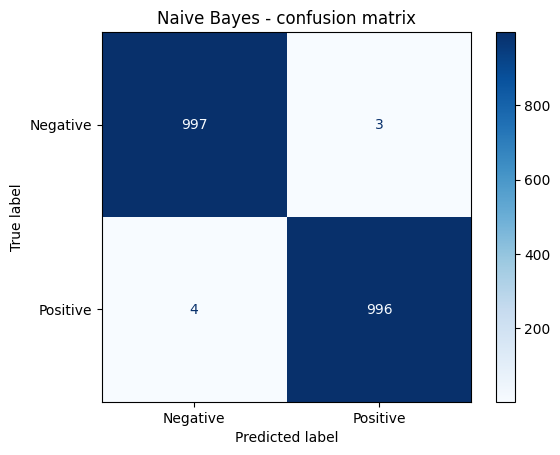

In [13]:
nb_pred = nb_model.predict(test_df['tokens'])
nb_scores = evaluate('Naive Bayes', y_test, nb_pred)

## 13. Words ranked by positive / negative ratio

**What:** for every word, compute `ratio = (positive count + 1) / (negative count + 1)` and list the extreme ones.
A high ratio means a strongly positive word; a low ratio, a strongly negative one.

**Why:** it is a quick, human-readable way to see *what the model has learned* and to sanity-check it: positive
emoticons and words like *thank* should sit at the top, `:(` at the bottom. The `+1` avoids dividing by zero.
The `lambda` is a reusable filter: label `1` keeps ratios at or above the threshold, label `0` keeps those at or below it.

In [14]:
freq_df['ratio'] = (freq_df['pos'] + 1) / (freq_df['neg'] + 1)

# label 1 -> ratio at or above threshold, label 0 -> ratio at or below threshold
words_by_threshold = lambda label, thr: freq_df[freq_df['ratio'] >= thr if label == 1 else freq_df['ratio'] <= thr]

print('Most negative words (ratio <= 0.05)')
display(words_by_threshold(0, 0.05)[['pos', 'neg', 'ratio']].sort_values('ratio').head(10))

print('Most positive words (ratio >= 10)')
display(words_by_threshold(1, 10)[['pos', 'neg', 'ratio']].sort_values('ratio', ascending=False).head(10))

Most negative words (ratio <= 0.05)


,pos,neg,ratio
:(,0,3646,0.000274
:-(,0,409,0.002439
》,0,180,0.005525
♛,0,180,0.005525
>:(,0,40,0.024390
justi̇n,0,30,0.032258
wi̇ll,0,30,0.032258
beli̇ev,0,30,0.032258
ｍｅ,0,30,0.032258
ｓｅｅ,0,30,0.032258


Most positive words (ratio >= 10)


,pos,neg,ratio
:),2937,2,979.333333
:-),568,0,569.000000
:d,556,0,557.000000
:p,114,0,115.000000
stat,42,0,43.000000
warsaw,34,0,35.000000
fback,26,0,27.000000
;),22,0,23.000000
here',21,0,22.000000
followfriday,20,0,21.000000


## 14. Error analysis

**What:** list the test tweets Naive Bayes misclassified.

**Why:** same reason as step 9. Naive Bayes assumes words are independent and ignores word order, so it can fail on
negation (*"not happy"*) or sarcasm. Reading the errors shows whether that is what happens here.

In [15]:
nb_errors = test_df.loc[test_df['label'] != nb_pred, ['tweet', 'tokens', 'label']].copy()
nb_errors['predicted'] = nb_pred[nb_errors.index]

print(f'{len(nb_errors)} misclassified tweets')
nb_errors.head(10)

7 misclassified tweets


,tweet,tokens,label,predicted
130,carter: I don't deserve this hate :(\nme: and ...,"[carter, deserv, hate, :(, deserv, singl, corn...",0,1
850,@ellekagaoan @chinmarquez Catch up once in a w...,"[catch, :(, >:d]",1,0
863,@phenomyoutube u probs had more fun with david...,"[u, prob, fun, david]",0,1
988,@taemihns halsey : ),[halsey],1,0
1421,off to the park to get some sunlight : ),"[park, get, sunlight]",1,0
1453,@bae_ts WHATEVER STIL L YOUNG &gt;:-(,"[whatev, stil, l, young, >:-(]",0,1
1882,Remember that one time I didn't go to flume/ka...,"[rememb, one, time, go, flume, kaytranada, alu...",1,0


# Part C: Compare and predict

## 15. Model comparison

**What:** put the metrics of both models in one table.

**Why:** the whole point of training two models is to compare them. Because both used the same split, the same
cleaning and the same metrics, any difference in the table is due to the models themselves.

In [16]:
pd.DataFrame([lr_scores, nb_scores]).set_index('model').round(4)

,accuracy,precision,recall,f1
model,,,,
Logistic Regression,0.9950,0.993,0.997,0.9950
Naive Bayes,0.9965,0.997,0.996,0.9965


## 16. Predict your own tweets

**What:** run both trained models on new text. Edit `my_tweets` to try your own sentences.

**Why:** this is the real use of the project: classifying text the model has never seen. Each tweet goes through the
same cleaning and feature steps as the training data. Logistic Regression returns a probability of being positive;
Naive Bayes returns a log-odds score (above 0 = positive, below 0 = negative; larger magnitude = more confident).

In [17]:
def predict_tweets(tweets):
    """Return a DataFrame with the sentiment predicted by each model."""
    tokens = pd.Series([process_tweet(t) for t in tweets])

    lr_feats = pd.DataFrame({
        'pos_freq': tokens.apply(lambda toks: sum(pos_map.get(w, 0) for w in toks)),
        'neg_freq': tokens.apply(lambda toks: sum(neg_map.get(w, 0) for w in toks)),
    })
    lr_prob = lr_model.predict_proba(lr_feats)[:, 1]
    nb_logodds = nb_model.predict_log_proba(tokens)
    nb_logodds = nb_logodds[:, 1] - nb_logodds[:, 0]

    label = lambda positive: np.where(positive, 'Positive', 'Negative')
    return pd.DataFrame({
        'tweet': tweets,
        'LR P(positive)': lr_prob.round(3),
        'LR sentiment': label(lr_prob > 0.5),
        'NB log-odds': nb_logodds.round(2),
        'NB sentiment': label(nb_logodds > 0),
    })

my_tweets = [
    'I am happy because I am learning :)',
    'you are bad :(',
    'She smiled.',
    'this movie should have been great.',
    'This is a ridiculously bright movie. The plot was terrible and I was sad until the ending!',
]
predict_tweets(my_tweets)

,tweet,LR P(positive),LR sentiment,NB log-odds,NB sentiment
0,I am happy because I am learning :),1.000,Positive,9.80,Positive
1,you are bad :(,0.000,Negative,-9.44,Negative
2,She smiled.,0.613,Positive,1.81,Positive
3,this movie should have been great.,0.695,Positive,2.08,Positive
4,This is a ridiculously bright movie. The plot ...,0.393,Negative,-6.65,Negative


# Part D: Save the trained models

**What:** store both trained models in `pickle` files: `lr_model.pkl` and `nb_model.pkl`.

**Why:** training and preprocessing take time. Once saved, the Streamlit app can simply load these files and
predict straight away, with no retraining. Each file is a Python dictionary holding the trained model plus the
extra items the app needs (word counts, log prior, test results).

## 17. Collect what each model needs

**What:** gather everything the app must have to reproduce each model's predictions and show its results.

**Why:** a trained model alone is not enough.
* Logistic Regression needs the **word-count maps** that turn a new tweet into its two features.
* Naive Bayes needs its **classifier and vocabulary**. We save these instead of the whole pipeline because the
  `CountVectorizer` in our pipeline uses a `lambda`, which `pickle` cannot store. The vocabulary is all the
  vectorizer learned, so nothing is lost.
* Test scores, confusion matrices and misclassified tweets are stored so the app can show results without
  re-evaluating.

In [18]:
import pickle
import sklearn

label_name = {1: 'Positive', 0: 'Negative'}

info = {
    'n_train': len(train_df),
    'n_test': len(test_df),
    'vocab_size': len(freq_df),
    'sklearn_version': sklearn.__version__,   # pickles should be loaded with the same scikit-learn version
}

def misclassified_table(errors, preds):
    """Compact table of wrongly classified test tweets: tweet, actual, predicted."""
    table = errors[['tweet', 'label']].copy()
    table['actual'] = table['label'].map(label_name)
    table['predicted'] = pd.Series(preds, index=test_df.index).loc[table.index].map(label_name)
    return table[['tweet', 'actual', 'predicted']].reset_index(drop=True)

lr_bundle = {
    'model': lr_model,                        # Pipeline: StandardScaler + LogisticRegression
    'pos_map': pos_map,                       # word -> count in positive training tweets
    'neg_map': neg_map,                       # word -> count in negative training tweets
    'scores': lr_scores,
    'confusion_matrix': confusion_matrix(y_test, lr_pred),
    'misclassified': misclassified_table(lr_errors, lr_pred),
    'info': info,
}

nb_bundle = {
    'classifier': nb_model['clf'],            # trained MultinomialNB
    'vocabulary': nb_model['counts'].get_feature_names_out().tolist(),
    'logprior': logprior,
    'word_table': freq_df,                    # pos, neg, loglikelihood, ratio for every word
    'scores': nb_scores,
    'confusion_matrix': confusion_matrix(y_test, nb_pred),
    'misclassified': misclassified_table(nb_errors, nb_pred),
    'info': info,
}

print('LR bundle keys:', list(lr_bundle))
print('NB bundle keys:', list(nb_bundle))

LR bundle keys: ['model', 'pos_map', 'neg_map', 'scores', 'confusion_matrix', 'misclassified', 'info']
NB bundle keys: ['classifier', 'vocabulary', 'logprior', 'word_table', 'scores', 'confusion_matrix', 'misclassified', 'info']


## 18. Write the pickle files

**What:** serialize each dictionary to disk with `pickle.dump`.

**Why:** `'wb'` writes the file in binary mode, which is what pickle needs. The two files are saved next to the
notebook, where the Streamlit app will look for them.

In [19]:
from pathlib import Path

with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_bundle, f)

with open('nb_model.pkl', 'wb') as f:
    pickle.dump(nb_bundle, f)

for name in ('lr_model.pkl', 'nb_model.pkl'):
    print(f'{name}: {Path(name).stat().st_size / 1024:.0f} KB')

lr_model.pkl: 196 KB
nb_model.pkl: 777 KB


## 19. Check the saved files

**What:** load both files back and compare their predictions on the test set with the models still in memory.

**Why:** this proves the saved models are complete and behave identically. It is also exactly how the Streamlit
app will load them. For Naive Bayes, the vectorizer is rebuilt from the saved vocabulary.

> Only load pickle files you created yourself or trust. Unpickling can run code.

In [20]:
with open('lr_model.pkl', 'rb') as f:
    lr_loaded = pickle.load(f)
with open('nb_model.pkl', 'rb') as f:
    nb_loaded = pickle.load(f)

# Logistic Regression: same features -> same predictions
lr_same = np.array_equal(lr_loaded['model'].predict(X_test_lr), lr_pred)

# Naive Bayes: rebuild the vectorizer from the saved vocabulary, then use the saved classifier
vectorizer = CountVectorizer(analyzer=lambda tokens: tokens, vocabulary=nb_loaded['vocabulary'])
nb_same = np.array_equal(nb_loaded['classifier'].predict(vectorizer.transform(test_df['tokens'])), nb_pred)

print('Logistic Regression predictions identical:', lr_same)
print('Naive Bayes predictions identical:        ', nb_same)

Logistic Regression predictions identical: True
Naive Bayes predictions identical:         True
